<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/node_14_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NODE model

Continuous-time **Neural ODE** model of the 1/4 drone. State `x = [theta, theta_dot]` (angle and angular velocity); a neural network models the dynamics as a **second-order system**:

$$\dot\theta = \dot\theta,\qquad \ddot\theta = \mathrm{NN}(\theta,\dot\theta,u)$$

so only the acceleration is learned. Trained with short **rollouts (20 samples)** as mini-batches, integrated with `torchdiffeq` (RK4, zero-order-hold input). We train **three ANN architectures of increasing complexity** and compare them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy
from scipy.signal import savgol_filter

try:
    from torchdiffeq import odeint
except ImportError:
    !pip install -q torchdiffeq
    from torchdiffeq import odeint
try:
    from sysid import readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import readData

Ts = 0.05            # sampling time [s]
L = 20               # rollout length (mini-batch window)
DATASETS = ['multiseno', 'degraus', 'swept_sine']


## Load and preprocess data

Each dataset is sliced to 20-80 s and decimated (as for the NARX model). The (unmeasured) velocity is estimated from the angle with a Savitzky-Golay filter.

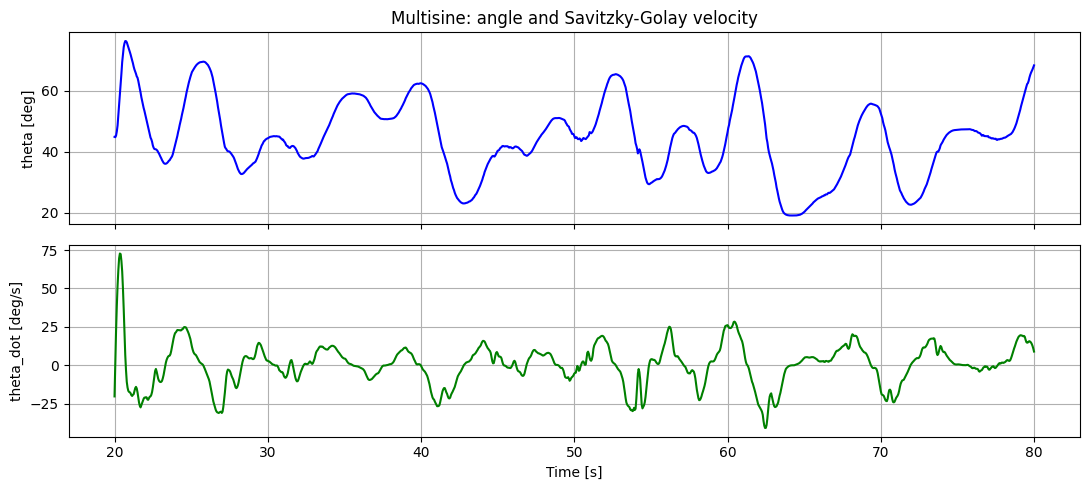

In [2]:
T_START, T_END, DECIMATION = 20.0, 80.0, 5
SG_WIN, SG_POLY = 11, 3

def load_processed(name):
    y, u, t, ref = readData('quarter_drone', name, return_ref=True)
    idx = np.where((t >= T_START) & (t <= T_END))[0]
    sl = slice(idx[0], idx[-1] + 1, DECIMATION)
    theta = y[sl].astype(float); u_s = u[sl].astype(float); t_s = t[sl].astype(float)
    theta_dot = savgol_filter(theta, SG_WIN, SG_POLY, deriv=1, delta=Ts)
    return dict(u=u_s, theta=theta, theta_dot=theta_dot, t=t_s)

data = {n: load_processed(n) for n in DATASETS}

d = data['multiseno']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a1.plot(d['t'], d['theta'], 'b'); a1.set_ylabel('theta [deg]'); a1.grid(True)
a1.set_title('Multisine: angle and Savitzky-Golay velocity')
a2.plot(d['t'], d['theta_dot'], 'g'); a2.set_ylabel('theta_dot [deg/s]')
a2.set_xlabel('Time [s]'); a2.grid(True)
plt.tight_layout(); plt.show()


## Interleaved train / test split

Each dataset is divided into five contiguous 20% blocks, alternating **train / test / train / test / train** -> **60% train / 40% test** per dataset. The train blocks (of all datasets) are pooled into rollout windows; the test blocks are held out for evaluation.

In [3]:
N_BLOCKS = 5
TRAIN_BLOCKS, TEST_BLOCKS = [0, 2, 4], [1, 3]

def block_bounds(M):
    return [int(M * i / N_BLOCKS) for i in range(N_BLOCKS + 1)]

def split_blocks(seg):
    M = len(seg['theta']); bnd = block_bounds(M)
    tr, te = [], []
    for b in range(N_BLOCKS):
        blk = {k: v[bnd[b]:bnd[b+1]] for k, v in seg.items()}
        (tr if b in TRAIN_BLOCKS else te).append(blk)
    return tr, te

train_blocks, test_blocks = [], []
for n in DATASETS:
    tr, te = split_blocks(data[n]); train_blocks += tr; test_blocks += te

# normalization stats from the training blocks
cat = lambda key: np.concatenate([b[key] for b in train_blocks])
mu = torch.tensor([cat('theta').mean(), cat('theta_dot').mean(), cat('u').mean()], dtype=torch.float32)
sd = torch.tensor([cat('theta').std(),  cat('theta_dot').std(),  cat('u').std()],  dtype=torch.float32)
acc_std = float(np.std(savgol_filter(cat('theta'), SG_WIN, SG_POLY, deriv=2, delta=Ts)))

def make_windows(seg):
    th, thd, u = seg['theta'], seg['theta_dot'], seg['u']
    X0, US, TG = [], [], []
    for i in range(len(th) - L):
        X0.append([th[i], thd[i]]); US.append(u[i:i+L]); TG.append(th[i:i+L])
    return X0, US, TG

X0, US, TG = [], [], []
for blk in train_blocks:
    a, b, c = make_windows(blk); X0 += a; US += b; TG += c
X0 = torch.tensor(X0, dtype=torch.float32)
US = torch.tensor(US, dtype=torch.float32)
TG = torch.tensor(TG, dtype=torch.float32)
print(f'Training windows: {X0.shape[0]}  (L={L}, 60% of each of {len(DATASETS)} datasets)')


Training windows: 1983  (L=20, 60% of each of 3 datasets)


/var/folders/my/z8rf11j53ws1p4jhzq2_2k240000gn/T/ipykernel_32911/635222268.py:36: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  US = torch.tensor(US, dtype=torch.float32)


## Neural ODE (second-order) and the three ANN architectures

`dtheta/dt = theta_dot` (fixed) and `dtheta_dot/dt = NN([theta, theta_dot, u])`. The network sees normalized inputs and outputs an acceleration scaled by the training acceleration std. Three architectures of increasing complexity:

| version | hidden layers |
|---|---|
| **v1 (simple)**  | 3 -> 16 -> 1 |
| **v2 (medium)**  | 3 -> 64 -> 64 -> 1 |
| **v3 (complex)** | 3 -> 128 -> 128 -> 128 -> 1 |

In [4]:
class ODEFunc(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        layers = []; prev = 3
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh()]; prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
        self.u_seq = None

    def set_input(self, u_seq):
        self.u_seq = u_seq

    def forward(self, t, y):
        idx = min(max(int(t.item() / Ts + 1e-6), 0), self.u_seq.shape[1] - 1)
        u_t = self.u_seq[:, idx:idx+1]
        inp = torch.cat([(y[:, 0:1] - mu[0]) / sd[0],
                         (y[:, 1:2] - mu[1]) / sd[1],
                         (u_t      - mu[2]) / sd[2]], dim=1)
        acc = self.net(inp) * acc_std
        return torch.cat([y[:, 1:2], acc], dim=1)

t_grid = torch.arange(L, dtype=torch.float32) * Ts

def free_run(func, seg):
    """Pure free-run rollout over a whole segment. Returns (prediction, RMSE_full)."""
    th, thd, u = seg['theta'], seg['theta_dot'], seg['u']
    func.set_input(torch.tensor(u[None, :], dtype=torch.float32))
    x0 = torch.tensor([[th[0], thd[0]]], dtype=torch.float32)
    tg = torch.arange(len(th), dtype=torch.float32) * Ts
    with torch.no_grad():
        pred = odeint(func, x0, tg, method='rk4')[:, 0, 0].numpy()
    return pred, float(np.sqrt(np.mean((pred - th) ** 2)))

ARCHITECTURES = {
    'v1 (3-16-1)':        [16],
    'v2 (3-64-64-1)':     [64, 64],
    'v3 (3-128-128-128-1)': [128, 128, 128],
}


## Training (with early stopping)

Each architecture is trained on the pooled 20-sample rollouts. Every few epochs we measure the in-sample free-run RMSE (on the training blocks only) and keep the best weights, which prevents the long-horizon free-run from degrading.

Training v1 (3-16-1) ...


   best in-sample free-run RMSE = 2.172
Training v2 (3-64-64-1) ...


   best in-sample free-run RMSE = 1.909
Training v3 (3-128-128-128-1) ...


   best in-sample free-run RMSE = 1.834


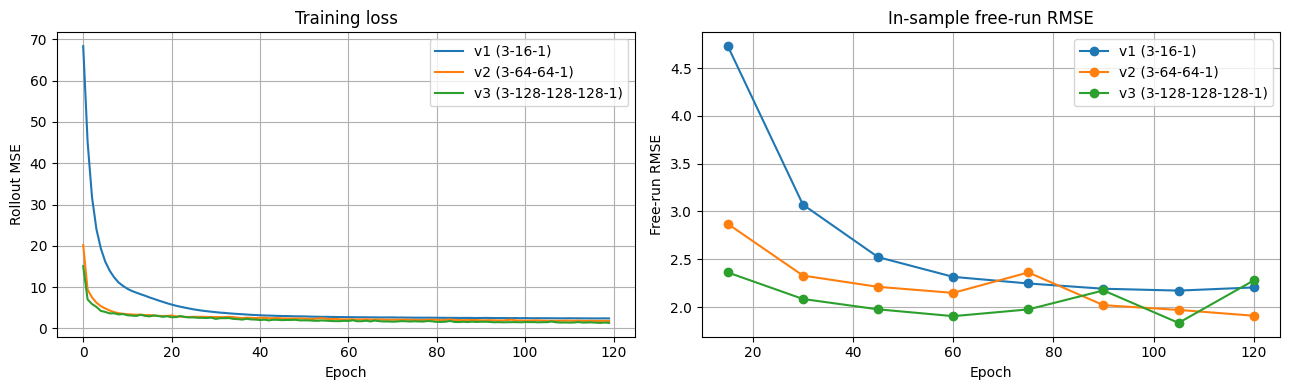

In [5]:
EPOCHS = 120
BATCH = 64
EVAL_EVERY = 15
N = X0.shape[0]

def train_node(hidden, seed=0):
    torch.manual_seed(seed)
    func = ODEFunc(hidden)
    opt = torch.optim.Adam(func.parameters(), lr=1e-3)
    loss_hist, valfr_hist, val_ep = [], [], []
    best_fr = float('inf'); best_state = copy.deepcopy(func.state_dict())
    for ep in range(EPOCHS):
        perm = torch.randperm(N); ep_loss = 0.0; nb = 0
        for i in range(0, N, BATCH):
            b = perm[i:i+BATCH]; func.set_input(US[b])
            pred = odeint(func, X0[b], t_grid, method='rk4')
            loss = ((pred[:, :, 0] - TG[b].T) ** 2).mean()
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(func.parameters(), 5.0); opt.step()
            ep_loss += loss.item(); nb += 1
        loss_hist.append(ep_loss / nb)
        if (ep + 1) % EVAL_EVERY == 0:
            fr = float(np.mean([free_run(func, blk)[1] for blk in train_blocks]))
            valfr_hist.append(fr); val_ep.append(ep + 1)
            if fr < best_fr:
                best_fr = fr; best_state = copy.deepcopy(func.state_dict())
    func.load_state_dict(best_state)
    return func, dict(loss=loss_hist, valfr=valfr_hist, val_ep=val_ep, best_fr=best_fr)

models, hist = {}, {}
for vname, hidden in ARCHITECTURES.items():
    print(f'Training {vname} ...')
    models[vname], hist[vname] = train_node(hidden)
    print(f'   best in-sample free-run RMSE = {hist[vname]["best_fr"]:.3f}')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
for vname in ARCHITECTURES:
    a1.plot(hist[vname]['loss'], label=vname)
    a2.plot(hist[vname]['val_ep'], hist[vname]['valfr'], 'o-', label=vname)
a1.set_xlabel('Epoch'); a1.set_ylabel('Rollout MSE'); a1.set_title('Training loss'); a1.legend(); a1.grid(True)
a2.set_xlabel('Epoch'); a2.set_ylabel('Free-run RMSE'); a2.set_title('In-sample free-run RMSE'); a2.legend(); a2.grid(True)
plt.tight_layout(); plt.show()


## Evaluation and comparison

Free-run over each **entire** dataset; the **test blocks** (held-out 20% stripes) are shaded and the RMSE is computed on them. The three architectures are overlaid for easy comparison.

architecture             multiseno     degraus  swept_sine
v1 (3-16-1)                  1.545       4.003       2.561
v2 (3-64-64-1)               2.512       5.711       2.102
v3 (3-128-128-128-1)         2.385       5.115       2.519


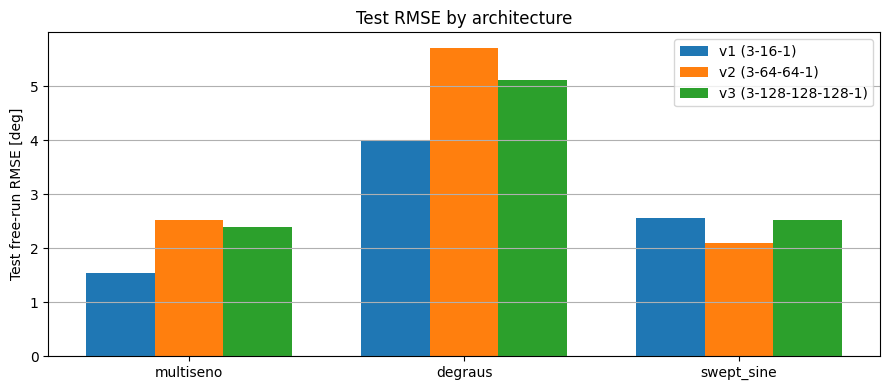

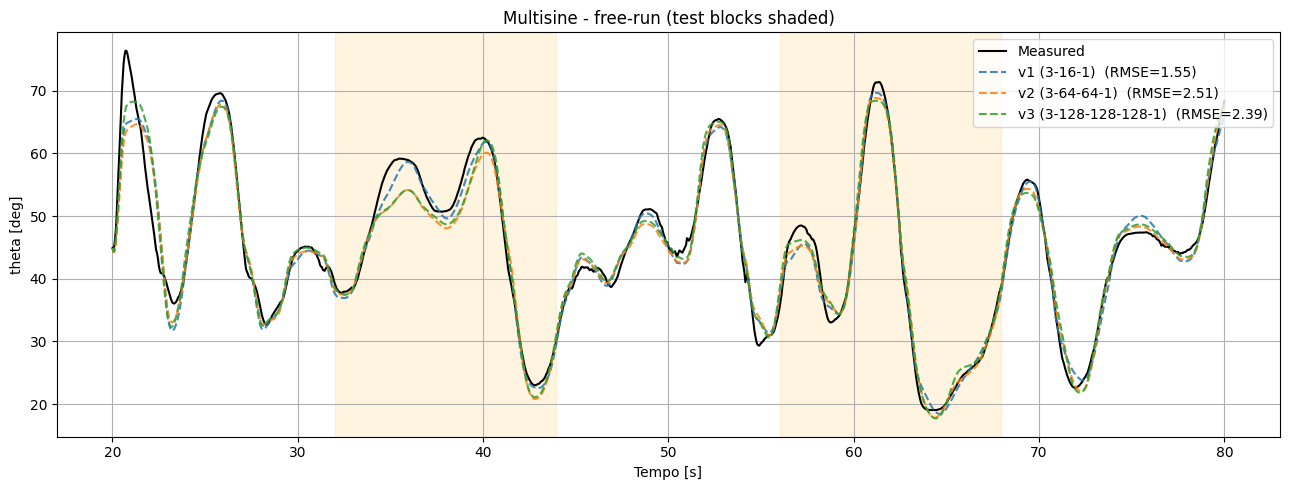

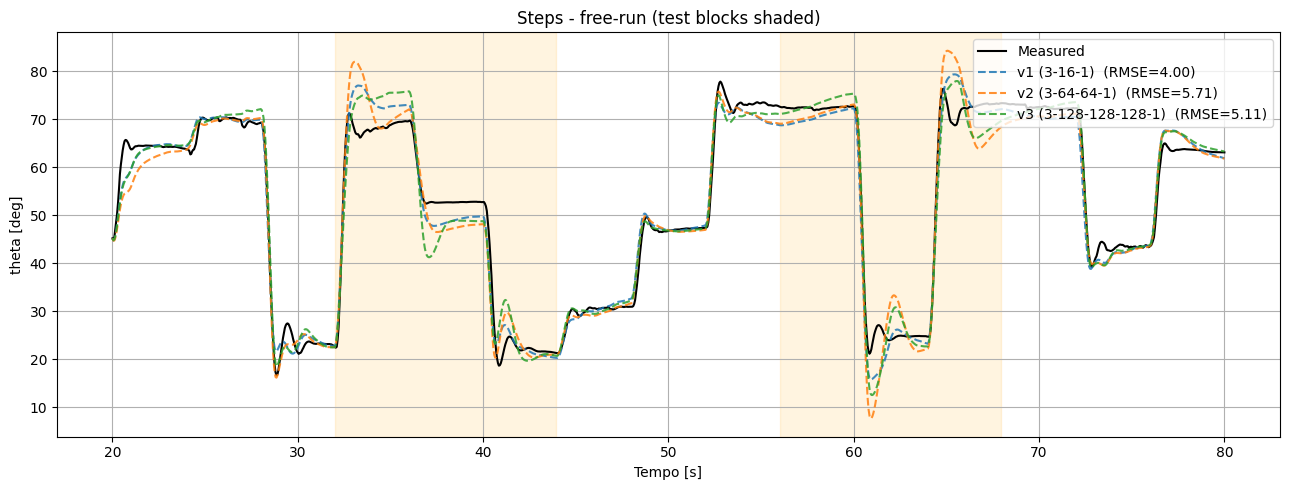

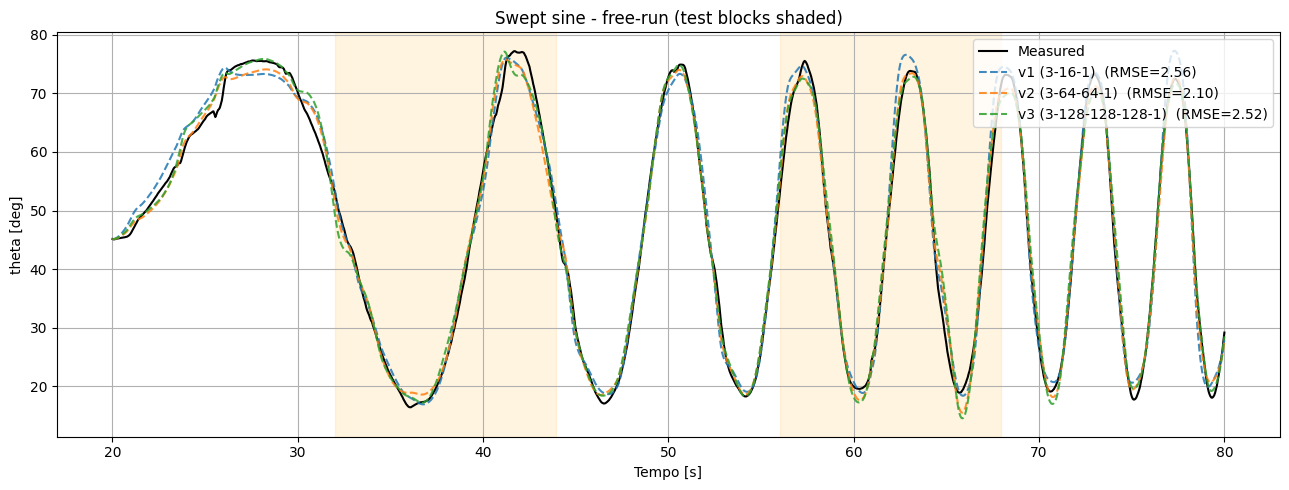

In [6]:
def eval_dataset(func, name):
    seg = data[name]; pred, _ = free_run(func, seg)
    M = len(seg['theta']); bnd = block_bounds(M)
    test_mask = np.zeros(M, bool)
    for b in TEST_BLOCKS: test_mask[bnd[b]:bnd[b+1]] = True
    rmse = float(np.sqrt(np.mean((pred[test_mask] - seg['theta'][test_mask]) ** 2)))
    return pred, rmse, bnd

# --- RMSE table ---
results = {v: {n: eval_dataset(models[v], n)[1] for n in DATASETS} for v in ARCHITECTURES}
print(f"{'architecture':22s} " + ' '.join(f'{n:>11s}' for n in DATASETS))
for v in ARCHITECTURES:
    print(f'{v:22s} ' + ' '.join(f'{results[v][n]:11.3f}' for n in DATASETS))

# --- bar chart ---
x = np.arange(len(DATASETS)); wd = 0.25
plt.figure(figsize=(9, 4))
for j, v in enumerate(ARCHITECTURES):
    plt.bar(x + (j - 1) * wd, [results[v][n] for n in DATASETS], wd, label=v)
plt.xticks(x, DATASETS); plt.ylabel('Test free-run RMSE [deg]')
plt.title('Test RMSE by architecture'); plt.legend(); plt.grid(True, axis='y')
plt.tight_layout(); plt.show()

# --- overlay free-run per dataset (test blocks shaded) ---
labels = {'multiseno': 'Multisine', 'degraus': 'Steps', 'swept_sine': 'Swept sine'}
for name in DATASETS:
    seg = data[name]; t, th = seg['t'], seg['theta']
    plt.figure(figsize=(13, 5))
    plt.plot(t, th, 'k', lw=1.5, label='Measured')
    for v in ARCHITECTURES:
        pred, rmse, bnd = eval_dataset(models[v], name)
        plt.plot(t, pred, '--', alpha=0.85, label=f'{v}  (RMSE={rmse:.2f})')
    for b in TEST_BLOCKS:
        plt.axvspan(t[bnd[b]], t[bnd[b+1]-1], color='orange', alpha=0.12)
    plt.title(f'{labels[name]} - free-run (test blocks shaded)')
    plt.xlabel('Tempo [s]'); plt.ylabel('theta [deg]')
    plt.legend(loc='upper right'); plt.grid(True); plt.tight_layout(); plt.show()
